# A* Algorithm Implementation

In [1]:
# Weighted Graph (Adjacency List)
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'D': 2, 'E': 5},
    'C': {'A': 4, 'F': 3},
    'D': {'B': 2},
    'E': {'B': 5, 'F': 1},
    'F': {'C': 3, 'E': 1, 'G': 2},
    'G': {'F': 2}
}

# Heuristic values (estimated cost to goal G)
heuristic = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 6,
    'E': 2,
    'F': 1,
    'G': 0   # goal node
}

In [2]:
import heapq

graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'D': 2, 'E': 5},
    'C': {'A': 4, 'F': 3},
    'D': {'B': 2},
    'E': {'B': 5, 'F': 1},
    'F': {'C': 3, 'E': 1, 'G': 2},
    'G': {'F': 2}
}

heuristic = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 6,
    'E': 2,
    'F': 1,
    'G': 0
}

def a_star(start, goal):
    open_list = []
    heapq.heappush(open_list, (0 + heuristic[start], 0, start, []))

    visited = set()

    while open_list:
        f, g, node, path = heapq.heappop(open_list)

        if node in visited:
            continue

        path = path + [node]

        if node == goal:
            return path, g

        visited.add(node)

        for neighbor, cost in graph[node].items():
            if neighbor not in visited:
                new_g = g + cost
                new_f = new_g + heuristic[neighbor]
                heapq.heappush(open_list, (new_f, new_g, neighbor, path))

    return None, float('inf')

# Run A*
path, cost = a_star('A', 'G')

print("Shortest Path:", path)
print("Total Cost:", cost)

Shortest Path: ['A', 'B', 'E', 'F', 'G']
Total Cost: 9


In [6]:

# Graph with weights
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 3)],
    'D': [],
    'E': [('F', 1)],
    'F': []
}

# Heuristic values
heuristic = {
    'A': 7,
    'B': 6,
    'C': 2,
    'D': 1,
    'E': 1,
    'F': 0
}

def a_star_steps(start, goal):
    open_list = [start]
    closed_list = []

    g = {start: 0}
    parent = {start: None}

    step = 1

    while open_list:
        # sort based on f(n)
        open_list.sort(key=lambda node: g[node] + heuristic[node])

        current = open_list.pop(0)

        print(f"\nStep {step}")
        print("Current Node:", current)

        # Goal check
        if current == goal:
            print("\nGoal reached!")
            path = []
            while current:
                path.append(current)
                current = parent[current]
            print("Path:", path[::-1])
            return

        closed_list.append(current)

        print("Open List:", open_list)
        print("Closed List:", closed_list)

        for neighbor, weight in graph[current]:
            new_cost = g[current] + weight

            if neighbor not in g or new_cost < g[neighbor]:
                g[neighbor] = new_cost
                parent[neighbor] = current

                if neighbor not in open_list and neighbor not in closed_list:
                    open_list.append(neighbor)

        # Show f(n) values
        print("f(n) values:")
        for node in open_list:
            print(f"{node} : g={g[node]}, h={heuristic[node]}, f={g[node]+heuristic[node]}")

        step += 1

# Run
a_star_steps('A', 'F')



Step 1
Current Node: A
Open List: []
Closed List: ['A']
f(n) values:
B : g=1, h=6, f=7
C : g=4, h=2, f=6

Step 2
Current Node: C
Open List: ['B']
Closed List: ['A', 'C']
f(n) values:
B : g=1, h=6, f=7
F : g=7, h=0, f=7

Step 3
Current Node: B
Open List: ['F']
Closed List: ['A', 'C', 'B']
f(n) values:
F : g=7, h=0, f=7
D : g=3, h=1, f=4
E : g=6, h=1, f=7

Step 4
Current Node: D
Open List: ['F', 'E']
Closed List: ['A', 'C', 'B', 'D']
f(n) values:
F : g=7, h=0, f=7
E : g=6, h=1, f=7

Step 5
Current Node: F

Goal reached!
Path: ['A', 'C', 'F']


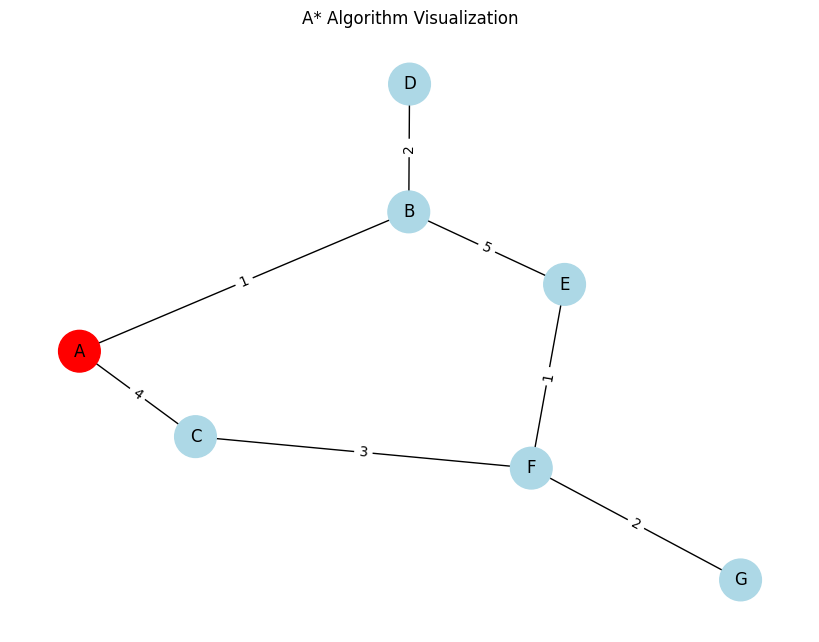

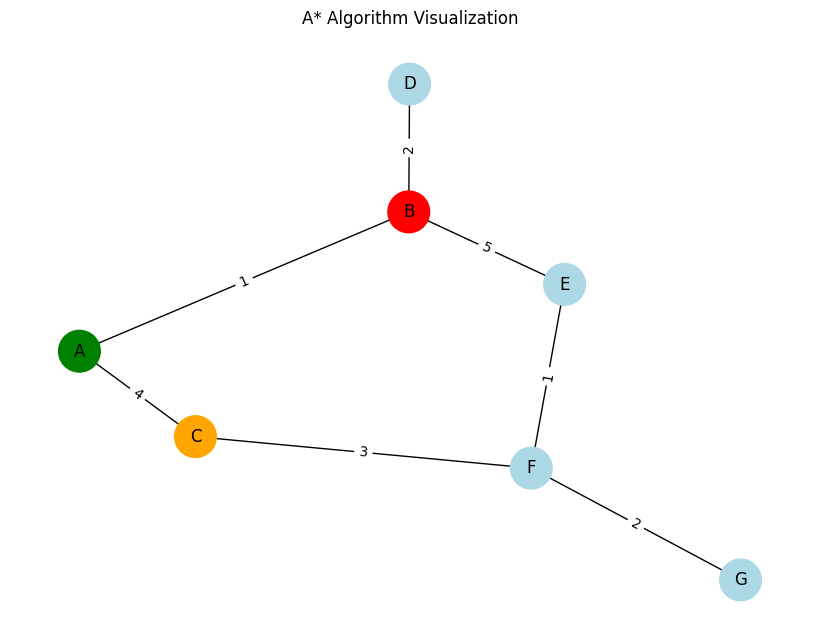

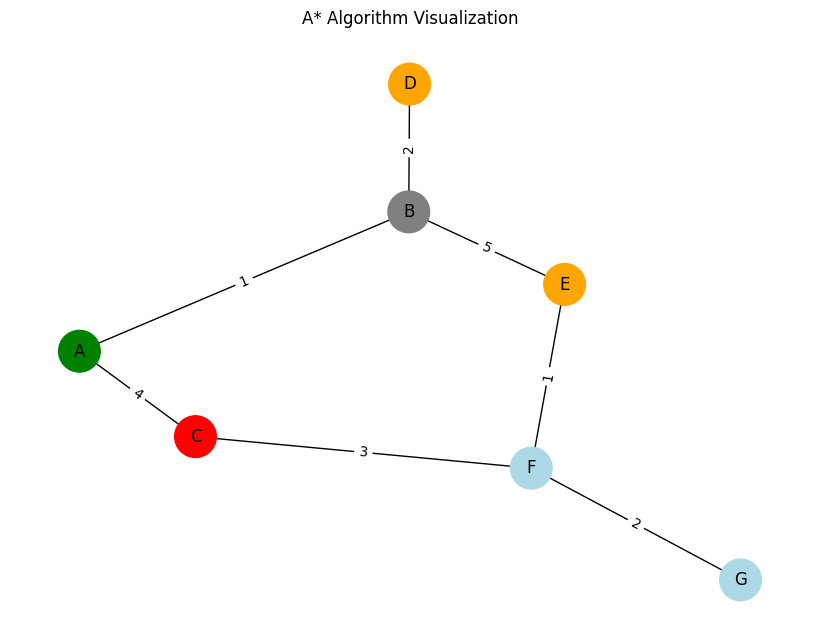

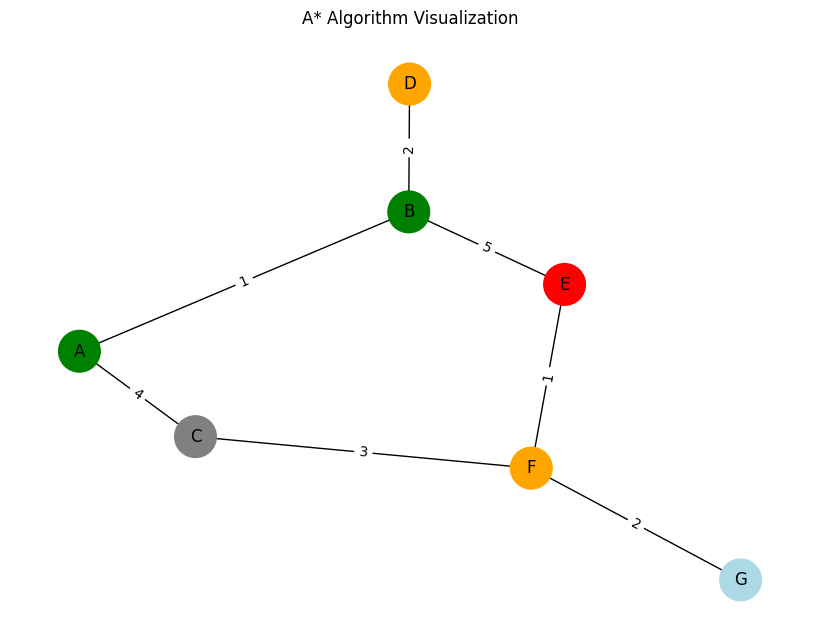

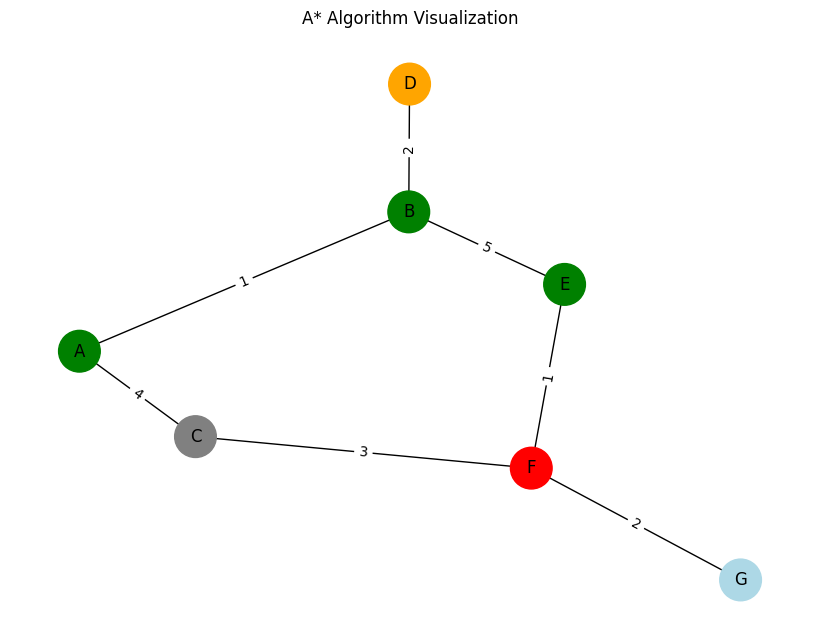

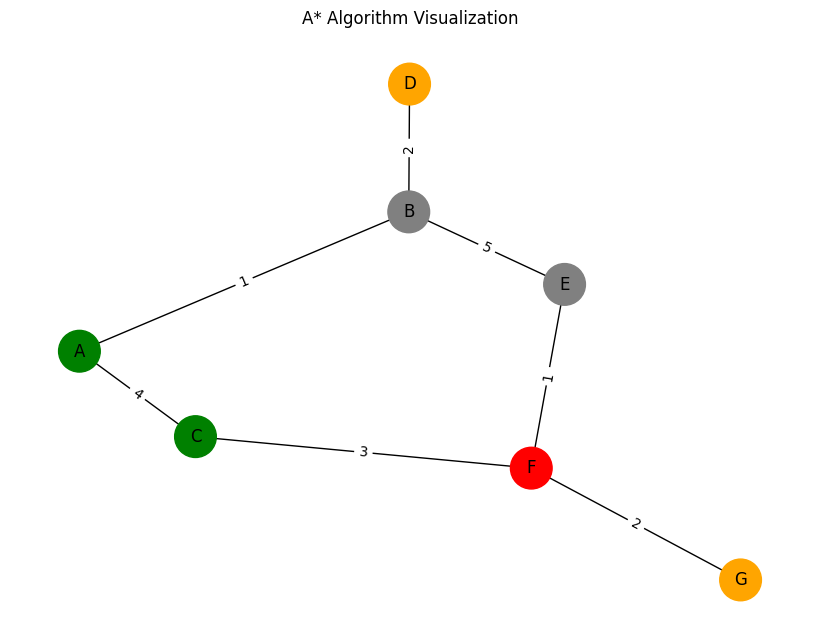

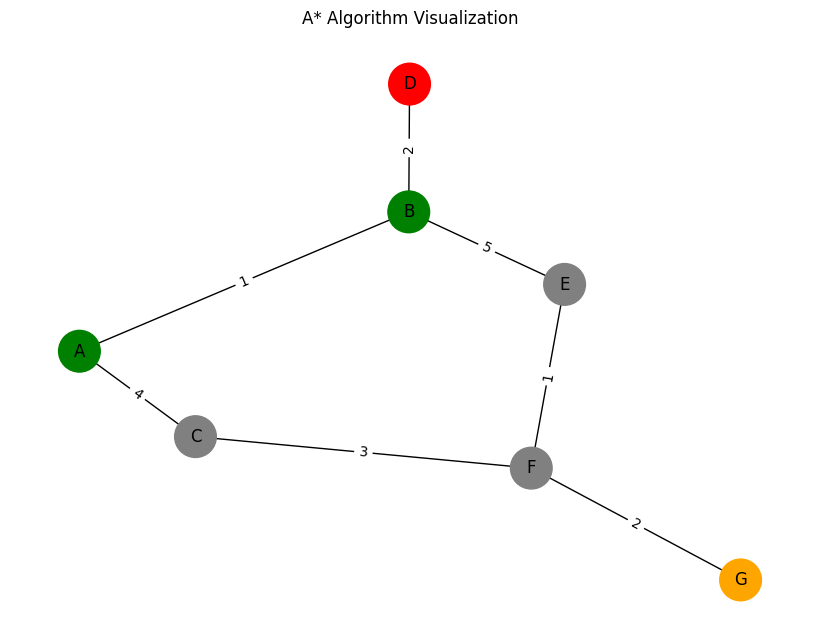

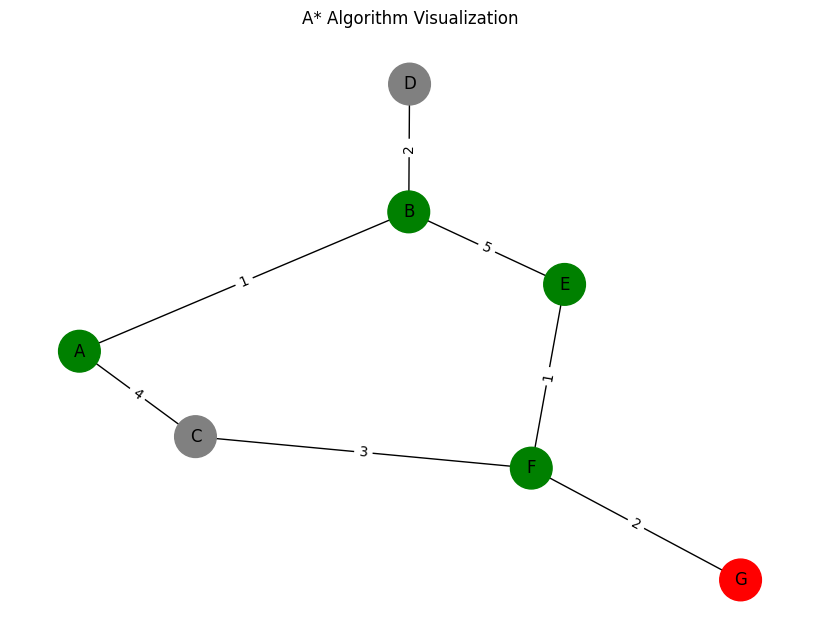

Final Path: ['A', 'B', 'E', 'F', 'G']
Cost: 9


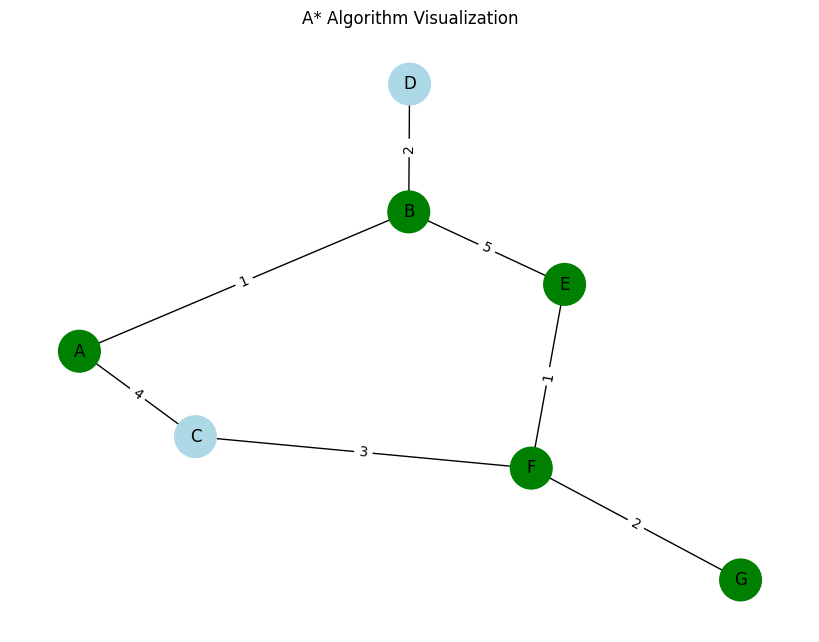

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import time

# ---------------- GRAPH ----------------
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'D': 2, 'E': 5},
    'C': {'A': 4, 'F': 3},
    'D': {'B': 2},
    'E': {'B': 5, 'F': 1},
    'F': {'C': 3, 'E': 1, 'G': 2},
    'G': {'F': 2}
}

heuristic = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 6,
    'E': 2,
    'F': 1,
    'G': 0
}

# ---------------- CREATE NETWORKX GRAPH ----------------
G = nx.Graph()

for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)

pos = nx.spring_layout(G, seed=42)  # fixed layout

# ---------------- DRAW FUNCTION ----------------
def draw_graph(current=None, open_set=[], closed_set=[], path=[]):
    plt.figure(figsize=(8,6))

    node_colors = []
    for node in G.nodes():
        if node == current:
            node_colors.append('red')        # current node
        elif node in path:
            node_colors.append('green')      # final path
        elif node in closed_set:
            node_colors.append('gray')       # visited
        elif node in open_set:
            node_colors.append('orange')     # open list
        else:
            node_colors.append('lightblue')

    nx.draw(G, pos, with_labels=True, node_color=node_colors,
            node_size=900, font_size=12)

    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.title("A* Algorithm Visualization")
    plt.show()


# ---------------- A* WITH VISUALIZATION ----------------
import heapq

def a_star_visual(start, goal):
    open_list = []
    heapq.heappush(open_list, (heuristic[start], 0, start, []))

    open_set = set([start])
    closed_set = set()

    while open_list:
        f, g, node, path = heapq.heappop(open_list)
        open_set.discard(node)
        closed_set.add(node)

        path = path + [node]

        # visualize step
        draw_graph(current=node, open_set=list(open_set), closed_set=list(closed_set), path=path)
        time.sleep(1)

        if node == goal:
            print("Final Path:", path)
            print("Cost:", g)
            draw_graph(path=path)
            return

        for neighbor, cost in graph[node].items():
            if neighbor not in closed_set:
                new_g = g + cost
                new_f = new_g + heuristic[neighbor]
                heapq.heappush(open_list, (new_f, new_g, neighbor, path))
                open_set.add(neighbor)

# ---------------- RUN ----------------
a_star_visual('A', 'G')